In [7]:
from pystac_client import Client
from datetime import datetime
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr
from shapely import geometry
from rich import inspect

# Set up a local cluster for distributed computing.
from distributed import LocalCluster

In [2]:
harz_boundaries = gpd.read_file("resources/Nationalpark_Harz_boundaries.geojson")
bbox = harz_boundaries.geometry.values[0].bounds

In [5]:
catalog = Client.open("https://stac.core.eopf.eodc.eu")

In [6]:
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2025-04-30", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")

In [8]:
r10m

<xarray.Dataset> Size: 15GB
Dimensions:      (time: 2, y: 10980, x: 20982)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [12]:
inspect(r10m)

╭───────────────────────────────────── <class 'xarray.core.dataset.Dataset'> ─────────────────────────────────────╮
│ A multi-dimensional, in memory, array database.                                                                 │
│                                                                                                                 │
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ <xarray.Dataset> Size: 15GB                                                                                 │ │
│ │ Dimensions:      (time: 2, y: 10980, x: 20982)                                                              │ │
│ │ Coordinates:                                                                                                │ │
│ │   * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                            │ │
│ │   * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                                 │ │
│ │   * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                              │ │
│ │ │   spatial_ref  int64 8B 0                                                                                 │ │
│ │ Data variables:                                                                                             │ │
│ │ │   b02          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>            │ │
│ │ │   b03          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>            │ │
│ │ │   b04          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>            │ │
│ │ │   b08          (time, y, x) float64 4GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>            │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│       attrs = {}                                                                                                │
│         b02 = <xarray.DataArray 'b02' (time: 2, y: 10980, x: 20982)> Size: 4GB                                  │
│               dask.array<concatenate, shape=(2, 10980, 20982), dtype=float64, chunksize=(1, 1830, 1830),        │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                  │
│                 * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                       │
│                 * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                    │
│                   spatial_ref  int64 8B 0                                                                       │
│               Attributes: (13)                                                                                  │
│         b03 = <xarray.DataArray 'b03' (time: 2, y: 10980, x: 20982)> Size: 4GB                                  │
│               dask.array<concatenate, shape=(2, 10980, 20982), dtype=float64, chunksize=(1, 1830, 1830),        │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                  │
│                 * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                       │
│                 * x            (x) int64 168kB 499985 

In [13]:
inspect(r10m.isel(time=0))

╭───────────────────────────────────── <class 'xarray.core.dataset.Dataset'> ─────────────────────────────────────╮
│ A multi-dimensional, in memory, array database.                                                                 │
│                                                                                                                 │
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ <xarray.Dataset> Size: 7GB                                                                                  │ │
│ │ Dimensions:      (y: 10980, x: 20982)                                                                       │ │
│ │ Coordinates:                                                                                                │ │
│ │   * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                                 │ │
│ │   * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                              │ │
│ │ │   time         datetime64[ns] 8B 2025-04-30T10:27:01.024000                                               │ │
│ │ │   spatial_ref  int64 8B 0                                                                                 │ │
│ │ Data variables:                                                                                             │ │
│ │ │   b02          (y, x) float64 2GB dask.array<chunksize=(1830, 1830), meta=np.ndarray>                     │ │
│ │ │   b03          (y, x) float64 2GB dask.array<chunksize=(1830, 1830), meta=np.ndarray>                     │ │
│ │ │   b04          (y, x) float64 2GB dask.array<chunksize=(1830, 1830), meta=np.ndarray>                     │ │
│ │ │   b08          (y, x) float64 2GB dask.array<chunksize=(1830, 1830), meta=np.ndarray>                     │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│       attrs = {}                                                                                                │
│         b02 = <xarray.DataArray 'b02' (y: 10980, x: 20982)> Size: 2GB                                           │
│               dask.array<getitem, shape=(10980, 20982), dtype=float64, chunksize=(1830, 1830),                  │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                       │
│                 * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                    │
│                   time         datetime64[ns] 8B 2025-04-30T10:27:01.024000                                     │
│                   spatial_ref  int64 8B 0                                                                       │
│               Attributes: (13)                                                                                  │
│         b03 = <xarray.DataArray 'b03' (y: 10980, x: 20982)> Size: 2GB                                           │
│               dask.array<getitem, shape=(10980, 20982), dtype=float64, chunksize=(1830, 1830),                  │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                       │
│                 * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                    │
│                   time         datetime64[ns] 8B 2025-

In [14]:
r10m.isel(time=0).b02

<xarray.DataArray 'b02' (y: 10980, x: 20982)> Size: 2GB
dask.array<getitem, shape=(10980, 20982), dtype=float64, chunksize=(1830, 1830), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Attributes: (13)

In [8]:
coarsed_r10m = r10m.coarsen(x=100, y=100, boundary="trim").mean()

In [9]:
inspect(coarsed_r10m)

╭───────────────────────────────────── <class 'xarray.core.dataset.Dataset'> ─────────────────────────────────────╮
│ A multi-dimensional, in memory, array database.                                                                 │
│                                                                                                                 │
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ <xarray.Dataset> Size: 1MB                                                                                  │ │
│ │ Dimensions:      (time: 2, y: 109, x: 209)                                                                  │ │
│ │ Coordinates:                                                                                                │ │
│ │   * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                            │ │
│ │   * y            (y) float64 872B 5.8e+06 5.799e+06 ... 5.693e+06 5.692e+06                                 │ │
│ │   * x            (x) float64 2kB 5.005e+05 5.015e+05 ... 7.075e+05 7.085e+05                                │ │
│ │ │   spatial_ref  int64 8B 0                                                                                 │ │
│ │ Data variables:                                                                                             │ │
│ │ │   b02          (time, y, x) float64 364kB dask.array<chunksize=(1, 18, 18), meta=np.ndarray>              │ │
│ │ │   b03          (time, y, x) float64 364kB dask.array<chunksize=(1, 18, 18), meta=np.ndarray>              │ │
│ │ │   b04          (time, y, x) float64 364kB dask.array<chunksize=(1, 18, 18), meta=np.ndarray>              │ │
│ │ │   b08          (time, y, x) float64 364kB dask.array<chunksize=(1, 18, 18), meta=np.ndarray>              │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│       attrs = {}                                                                                                │
│         b02 = <xarray.DataArray 'b02' (time: 2, y: 109, x: 209)> Size: 364kB                                    │
│               dask.array<mean_agg-aggregate, shape=(2, 109, 209), dtype=float64, chunksize=(1, 18, 18),         │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                  │
│                 * y            (y) float64 872B 5.8e+06 5.799e+06 ... 5.693e+06 5.692e+06                       │
│                 * x            (x) float64 2kB 5.005e+05 5.015e+05 ... 7.075e+05 7.085e+05                      │
│                   spatial_ref  int64 8B 0                                                                       │
│               Attributes: (13)                                                                                  │
│         b03 = <xarray.DataArray 'b03' (time: 2, y: 109, x: 209)> Size: 364kB                                    │
│               dask.array<mean_agg-aggregate, shape=(2, 109, 209), dtype=float64, chunksize=(1, 18, 18),         │
│               chunktype=numpy.ndarray>                                                                          │
│               Coordinates:                                                                                      │
│                 * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                  │
│                 * y            (y) float64 872B 5.8e+06 5.799e+06 ... 5.693e+06 5.692e+06                       │
│                 * x            (x) float64 2kB 5.005e+

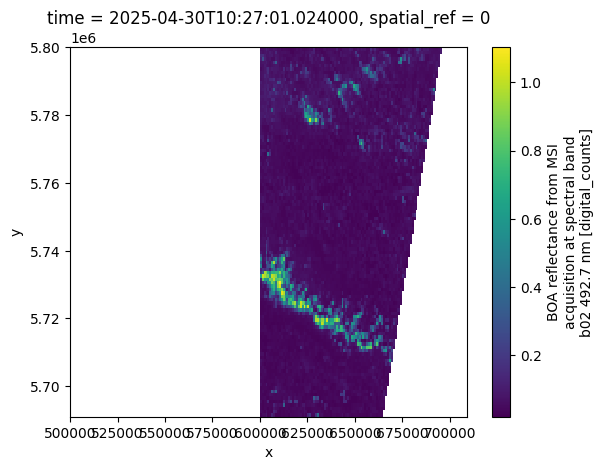

In [11]:
coarsed_r10m.b02.isel(time=0).plot()

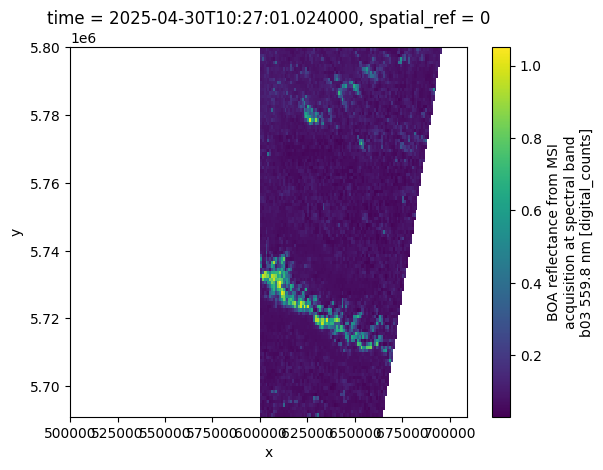

In [12]:
coarsed_r10m.b03.isel(time=0).plot()

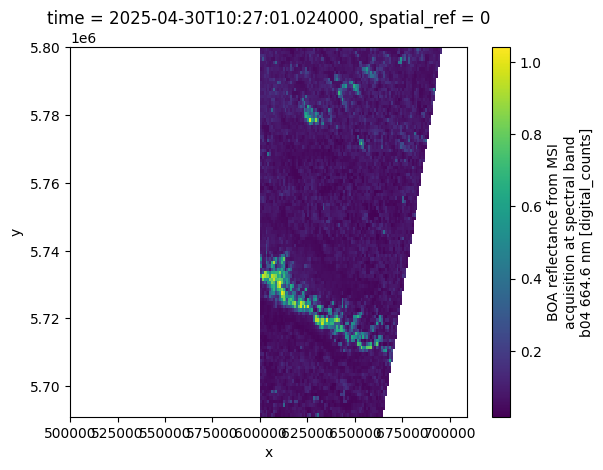

In [13]:
coarsed_r10m.b04.isel(time=0).plot()

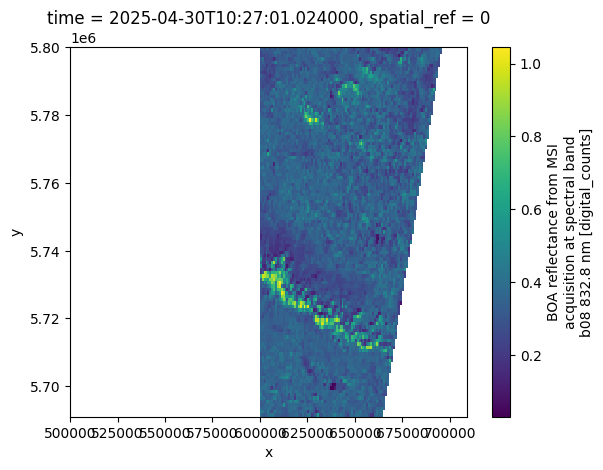

In [14]:
coarsed_r10m.b08.isel(time=0).plot()

In [17]:
r10m['test'] = xr.zeros_like(r10m['b02'])

In [18]:
inspect(r10m['test'])

╭─────────────────────────────────── <class 'xarray.core.dataarray.DataArray'> ───────────────────────────────────╮
│ N-dimensional array with labeled coordinates and dimensions.                                                    │
│                                                                                                                 │
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ <xarray.DataArray 'test' (time: 2, y: 10980, x: 20982)> Size: 4GB                                           │ │
│ │ dask.array<full_like, shape=(2, 10980, 20982), dtype=float64, chunksize=(1, 1830, 1830),                    │ │
│ │ chunktype=numpy.ndarray>                                                                                    │ │
│ │ Coordinates:                                                                                                │ │
│ │   * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...                            │ │
│ │   * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225                                 │ │
│ │   * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795                              │ │
│ │ │   spatial_ref  int64 8B 0                                                                                 │ │
│ │ Attributes: (13)                                                                                            │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│          attrs = {                                                                                              │
│                      '_eopf_attrs': {                                                                           │
│                          'add_offset': -0.1,                                                                    │
│                          'coordinates': ['x', 'y'],                                                             │
│                          'dimensions': ['y', 'x'],                                                              │
│                          'dtype': '<u2',                                                                        │
│                          'fill_value': 0,                                                                       │
│                          'long_name': 'BOA reflectance from MSI acquisition at spectral band b02 492.7 nm',     │
│                          'scale_factor': 0.0001,                                                                │
│                          'units': 'digital_counts'                                                              │
│                      },                                                                                         │
│                      'dtype': '<u2',                                                                            │
│                      'fill_value': 0,                                                                           │
│                      'long_name': 'BOA reflectance from MSI acquisition at spectral band b02 492.7 nm',         │
│                      'proj:bbox': [600000.0, 5690220.0, 709800.0, 5800020.0],                                   │
│                      'proj:epsg': 32632,                                                                        │
│                      'proj:shape': [10980, 10980],                                                              │
│                      'proj:transform': [10.0, 0.0, 600000.0, 0.0, -10.0, 5800020.0, 0.0, 0.0, 1.0],             │
│                      'proj:wkt2': 'PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS                                   │
│                  84",DATUM["WGS_1984",SPHEROID["WGS   

In [19]:
r10m['ndvi'] = (r10m.b08 - r10m.b04) / (r10m.b08 + r10m.b04)

In [20]:
r10m.ndvi

<xarray.DataArray 'ndvi' (time: 2, y: 10980, x: 20982)> Size: 4GB
dask.array<truediv, shape=(2, 10980, 20982), dtype=float64, chunksize=(1, 1830, 1830), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 16B 2025-04-30 10:27:01.02400...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Attributes: (11)

In [23]:
coarsed_r10m = r10m.coarsen(x=100, y=100, boundary="trim").mean()

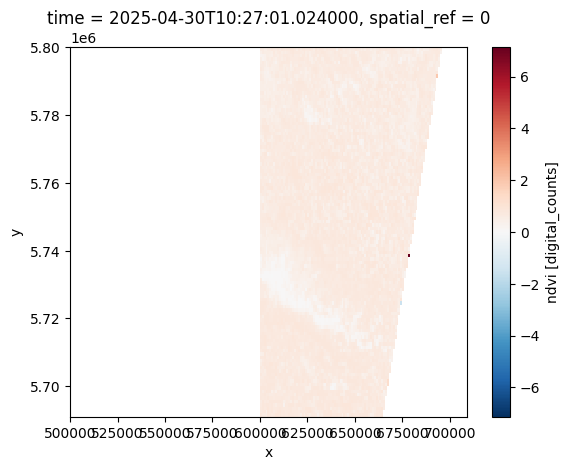

In [25]:
coarsed_r10m.ndvi.isel(time=0).plot()